In [17]:
# =========================
# STEP 2 CONFIG
# =========================

EPS_KM = 5.0
MIN_SAMPLES = 3
MIN_VISITS = 5   # keep consistent with Step 1

# sparse-label thresholds
SPARSE_MIN_VISITS = 8
SPARSE_MIN_UNIQUE_BUSINESSES = 3
SPARSE_MIN_UNIQUE_POINTS = 3
SPARSE_MIN_CLUSTERED_SHARE = 0.50

OUTPUT_DIR = r"C:\Users\lebro\OneDrive - Nanyang Technological University\Github\YelpFYP\step2_outputs"
OUTPUT_POP_CSV = fr"{OUTPUT_DIR}\user_mobility_table.csv"
OUTPUT_SUMMARY_JSON = fr"{OUTPUT_DIR}\mobility_summary.json"
OUTPUT_HUBS_CSV = fr"{OUTPUT_DIR}\user_hubs.csv"

In [5]:
from pathlib import Path

path = Path(r"C:\Users\lebro\OneDrive - Nanyang Technological University\Github\YelpFYP\step1_outputs\user_visit_events.parquet")

print("exists:", path.exists())
print("size (bytes):", path.stat().st_size if path.exists() else None)

with open(path, "rb") as f:
    head = f.read(64)

print("first 64 bytes:", head)

exists: True
size (bytes): 6056462
first 64 bytes: b'user_id,business_id,event_time,event_type,stars_x,name,latitude,'


In [6]:
import pandas as pd

path = r"C:\Users\lebro\OneDrive - Nanyang Technological University\Github\YelpFYP\step1_outputs\user_visit_events.parquet"

visits = pd.read_csv(path)

print(visits.shape)
print(visits.columns.tolist())
display(visits.head())

(27732, 14)
['user_id', 'business_id', 'event_time', 'event_type', 'stars_x', 'name', 'latitude', 'longitude', 'city', 'state', 'categories', 'stars_y', 'review_count', 'is_open']


,user_id,business_id,event_time,event_type,stars_x,name,latitude,longitude,city,state,categories,stars_y,review_count,is_open
0,---zemaUC8WeJeWKqS6p9Q,eX7o_-s5TmDT-DMfTV4cmw,2021-06-23 08:17:42+00:00,review,5.0,Luckys Steakhouse,34.421239,-119.641027,Montecito,CA,"Restaurants, Seafood, Nightlife, Steakhouses, ...",4.0,387,1
1,--z4j_95J4XLJJFrVHgBiw,IP_E4SHLClorhNg4o5bw9Q,2018-10-16 01:36:14+00:00,review,5.0,Rosy's Taco Bar,39.950896,-75.178367,Philadelphia,PA,"Tacos, Nightlife, Bars, Mexican, Restaurants",4.0,282,1
2,-0A675r8EE26FmhYx68KHw,3OGzmGqWwsyGLkhnxrA9Pw,2013-08-24 00:23:11+00:00,review,1.0,Gourmet Pizza Company,27.937948,-82.484684,Tampa,FL,"Pizza, Restaurants, Gluten-Free, Vegan",4.0,185,1
3,-0MIp6WKJ8QvGnYZQ5ETyg,UTgUhbpM5hRVDB8Nu7-lpw,2018-06-11 22:57:47+00:00,review,4.0,China Cafe,39.610539,-75.074803,Franklinville,NJ,"Chinese, Restaurants",4.0,18,1
4,-0MIp6WKJ8QvGnYZQ5ETyg,jwpZzqoPFLuHE-FwLp41cQ,2020-03-15 00:33:43+00:00,review,4.0,Bistro Di Marino,39.918191,-75.075328,Collingswood,NJ,"Italian, Salad, Restaurants, Seafood",4.0,285,1


In [19]:
required_cols = ["user_id", "business_id", "latitude", "longitude"]

missing = [c for c in required_cols if c not in visits.columns]
if missing:
    raise ValueError(f"visits is missing required columns: {missing}")

print("visits shape:", visits.shape)
print("unique users:", visits["user_id"].nunique())
display(visits.head())

visits shape: (27732, 14)
unique users: 7393


,user_id,business_id,event_time,event_type,stars_x,name,latitude,longitude,city,state,categories,stars_y,review_count,is_open
0,---zemaUC8WeJeWKqS6p9Q,eX7o_-s5TmDT-DMfTV4cmw,2021-06-23 08:17:42+00:00,review,5.0,Luckys Steakhouse,34.421239,-119.641027,Montecito,CA,"Restaurants, Seafood, Nightlife, Steakhouses, ...",4.0,387,1
1,--z4j_95J4XLJJFrVHgBiw,IP_E4SHLClorhNg4o5bw9Q,2018-10-16 01:36:14+00:00,review,5.0,Rosy's Taco Bar,39.950896,-75.178367,Philadelphia,PA,"Tacos, Nightlife, Bars, Mexican, Restaurants",4.0,282,1
2,-0A675r8EE26FmhYx68KHw,3OGzmGqWwsyGLkhnxrA9Pw,2013-08-24 00:23:11+00:00,review,1.0,Gourmet Pizza Company,27.937948,-82.484684,Tampa,FL,"Pizza, Restaurants, Gluten-Free, Vegan",4.0,185,1
3,-0MIp6WKJ8QvGnYZQ5ETyg,UTgUhbpM5hRVDB8Nu7-lpw,2018-06-11 22:57:47+00:00,review,4.0,China Cafe,39.610539,-75.074803,Franklinville,NJ,"Chinese, Restaurants",4.0,18,1
4,-0MIp6WKJ8QvGnYZQ5ETyg,jwpZzqoPFLuHE-FwLp41cQ,2020-03-15 00:33:43+00:00,review,4.0,Bistro Di Marino,39.918191,-75.075328,Collingswood,NJ,"Italian, Salad, Restaurants, Seafood",4.0,285,1


In [37]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

EARTH_KM = 6371.0

def haversine_km(lat1, lon1, lat2, lon2):
    a = np.radians([lat1, lon1, lat2, lon2])
    lat1, lon1, lat2, lon2 = a
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    h = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return float(2 * EARTH_KM * np.arcsin(np.sqrt(h)))

def dbscan_labels_latlon(dfu, eps_km=5.0, min_samples=3):
    coords = np.radians(dfu[["latitude", "longitude"]].to_numpy())
    db = DBSCAN(
        eps=eps_km / EARTH_KM,
        min_samples=min_samples,
        metric="haversine"
    ).fit(coords)
    return db.labels_

def summarize_user(dfu, eps_km=5.0, min_samples=3):
    dfu = dfu.copy()
    dfu["cluster"] = dbscan_labels_latlon(dfu, eps_km=eps_km, min_samples=min_samples)

    n_visits = len(dfu)
    n_unique_businesses = dfu["business_id"].nunique()
    n_unique_points = dfu[["latitude", "longitude"]].drop_duplicates().shape[0]

    noise_n = int((dfu["cluster"] == -1).sum())
    noise_ratio = noise_n / n_visits if n_visits else 0.0
    clustered_share = 1.0 - noise_ratio

    clusters = [c for c in sorted(dfu["cluster"].unique()) if c != -1]
    hubs = []

    for c in clusters:
        pts = dfu[dfu["cluster"] == c]
        hubs.append({
            "cluster": int(c),
            "size": int(len(pts)),
            "lat": float(pts["latitude"].mean()),
            "lon": float(pts["longitude"].mean())
        })

    hubs.sort(key=lambda x: x["size"], reverse=True)

    n_hubs = len(hubs)
    clustered_n = sum(h["size"] for h in hubs)

    hub1_size = hubs[0]["size"] if len(hubs) >= 1 else 0
    hub2_size = hubs[1]["size"] if len(hubs) >= 2 else 0

    hub1_share = (hub1_size / clustered_n) if clustered_n else 0.0
    hub2_share = (hub2_size / clustered_n) if clustered_n else 0.0

    hub_dist_km = None
    if len(hubs) >= 2:
        hub_dist_km = haversine_km(
            hubs[0]["lat"], hubs[0]["lon"],
            hubs[1]["lat"], hubs[1]["lon"]
        )

    travel_range_km = None
    max_dist_from_primary_hub_km = None

    if len(hubs) >= 1:
        h0 = hubs[0]
        primary_pts = dfu[dfu["cluster"] == h0["cluster"]]

        dists = primary_pts.apply(
            lambda r: haversine_km(h0["lat"], h0["lon"], r["latitude"], r["longitude"]),
            axis=1
        )

        if len(dists) > 0:
            travel_range_km = float(dists.median())
            max_dist_from_primary_hub_km = float(dists.max())

    return {
        "user_id": dfu["user_id"].iloc[0],
        "n_visits": int(n_visits),
        "n_unique_businesses": int(n_unique_businesses),
        "n_unique_points": int(n_unique_points),
        "n_hubs": int(n_hubs),
        "noise_ratio": float(noise_ratio),
        "clustered_share": float(clustered_share),
        "hub1_size": int(hub1_size),
        "hub2_size": int(hub2_size),
        "hub1_share": float(hub1_share),
        "hub2_share": float(hub2_share),
        "hub_dist_km": hub_dist_km,
        "travel_range_km": travel_range_km,
        "max_dist_from_primary_hub_km": max_dist_from_primary_hub_km,
    }

def extract_user_hubs(dfu, eps_km=5.0, min_samples=3):
    dfu = dfu.copy()
    dfu["cluster"] = dbscan_labels_latlon(dfu, eps_km=eps_km, min_samples=min_samples)

    clusters = [c for c in sorted(dfu["cluster"].unique()) if c != -1]
    hubs = []

    for c in clusters:
        pts = dfu[dfu["cluster"] == c]
        hubs.append({
            "user_id": dfu["user_id"].iloc[0],
            "cluster_id": int(c),
            "hub_size": int(len(pts)),
            "hub_lat": float(pts["latitude"].mean()),
            "hub_lon": float(pts["longitude"].mean()),
        })

    hubs = sorted(hubs, key=lambda x: x["hub_size"], reverse=True)
    for i, h in enumerate(hubs, start=1):
        h["hub_rank"] = i

    return hubs

def classify_mobility_sparse(row):
    n_visits = int(row["n_visits"])
    n_unique_businesses = int(row["n_unique_businesses"])
    n_unique_points = int(row["n_unique_points"])
    n_hubs = int(row["n_hubs"])

    hub1_share = float(row["hub1_share"]) if pd.notna(row["hub1_share"]) else 0.0
    hub2_share = float(row["hub2_share"]) if pd.notna(row["hub2_share"]) else 0.0
    hub2_size = int(row["hub2_size"]) if pd.notna(row["hub2_size"]) else 0
    hubd = float(row["hub_dist_km"]) if pd.notna(row["hub_dist_km"]) else None
    noise_ratio = float(row["noise_ratio"]) if pd.notna(row["noise_ratio"]) else 1.0
    clustered_share = float(row["clustered_share"]) if pd.notna(row["clustered_share"]) else 0.0

    # 1) not enough spatial evidence
    if (
        n_visits < SPARSE_MIN_VISITS or
        n_unique_businesses < SPARSE_MIN_UNIQUE_BUSINESSES or
        n_unique_points < SPARSE_MIN_UNIQUE_POINTS or
        clustered_share < SPARSE_MIN_CLUSTERED_SHARE
    ):
        return "sparse"

    # 2) one dominant area
    if n_hubs == 1 and hub1_share >= 0.70 and noise_ratio < 0.40:
        return "one_area"

    # 3) two meaningful areas
    if n_hubs >= 2 and hubd is not None:
        if hub2_size >= 3 and hub1_share >= 0.30 and hub2_share >= 0.20 and hubd <= 50:
            return "two_area"

    # 4) broad / scattered / multi-hub behaviour
    if noise_ratio >= 0.50 or n_hubs >= 3:
        return "explorer"

    # 5) remaining borderline cases
    return "explorer"

def classify_mobility_sparse_v2(row):
    n_visits = int(row["n_visits"])
    n_unique_businesses = int(row["n_unique_businesses"])
    n_unique_points = int(row["n_unique_points"])
    n_hubs = int(row["n_hubs"])

    hub1_share = float(row["hub1_share"]) if pd.notna(row["hub1_share"]) else 0.0
    hub2_share = float(row["hub2_share"]) if pd.notna(row["hub2_share"]) else 0.0
    hub2_size = int(row["hub2_size"]) if pd.notna(row["hub2_size"]) else 0
    hubd = float(row["hub_dist_km"]) if pd.notna(row["hub_dist_km"]) else None
    noise_ratio = float(row["noise_ratio"]) if pd.notna(row["noise_ratio"]) else 1.0
    clustered_share = float(row["clustered_share"]) if pd.notna(row["clustered_share"]) else 0.0

    if (
        n_visits < SPARSE_MIN_VISITS or
        n_unique_businesses < SPARSE_MIN_UNIQUE_BUSINESSES or
        n_unique_points < SPARSE_MIN_UNIQUE_POINTS or
        clustered_share < SPARSE_MIN_CLUSTERED_SHARE
    ):
        return "sparse"

    if n_hubs == 1 and hub1_share >= 0.80 and noise_ratio < 0.30:
        return "one_area"

    if n_hubs == 2 and hubd is not None:
        if hub2_size >= 3 and hub1_share >= 0.30 and hub2_share >= 0.20 and hubd <= 50:
            return "two_area"

    if n_hubs >= 3 or noise_ratio >= 0.40:
        return "explorer"

    return "explorer"

def classify_mobility_sparse_v3(row):
    n_visits = int(row["n_visits"])
    n_unique_businesses = int(row["n_unique_businesses"])
    n_unique_points = int(row["n_unique_points"])
    n_hubs = int(row["n_hubs"])

    hub1_size = int(row["hub1_size"]) if pd.notna(row["hub1_size"]) else 0
    hub2_size = int(row["hub2_size"]) if pd.notna(row["hub2_size"]) else 0
    hub1_share = float(row["hub1_share"]) if pd.notna(row["hub1_share"]) else 0.0
    hub2_share = float(row["hub2_share"]) if pd.notna(row["hub2_share"]) else 0.0
    hubd = float(row["hub_dist_km"]) if pd.notna(row["hub_dist_km"]) else None
    noise_ratio = float(row["noise_ratio"]) if pd.notna(row["noise_ratio"]) else 1.0
    clustered_share = float(row["clustered_share"]) if pd.notna(row["clustered_share"]) else 0.0
    max_dist_primary = (
        float(row["max_dist_from_primary_hub_km"])
        if pd.notna(row["max_dist_from_primary_hub_km"])
        else None
    )

    # 1) insufficient evidence
    if (
        n_visits < SPARSE_MIN_VISITS or
        n_unique_businesses < SPARSE_MIN_UNIQUE_BUSINESSES or
        n_unique_points < SPARSE_MIN_UNIQUE_POINTS or
        clustered_share < SPARSE_MIN_CLUSTERED_SHARE
    ):
        return "sparse"

    # 2) clear single-area behaviour
    if (
        n_hubs == 1 and
        hub1_size >= 5 and
        hub1_share >= 0.80 and
        noise_ratio < 0.30 and
        max_dist_primary is not None and
        max_dist_primary <= 30
    ):
        return "one_area"

    # 3) clear two-area behaviour
    if (
        n_hubs == 2 and
        hub1_size >= 3 and
        hub2_size >= 3 and
        hub1_share >= 0.30 and
        hub2_share >= 0.20 and
        clustered_share >= 0.70 and
        hubd is not None and
        hubd <= 50
    ):
        return "two_area"

    # 4) multi-hub or scattered users
    if n_hubs >= 3 or noise_ratio >= 0.40:
        return "explorer"

    # 5) remaining ambiguous cases
    return "explorer"
    

In [38]:
# =========================
# BUILD USER MOBILITY TABLE
# =========================

profile_rows = []
hub_rows = []

for uid, dfu in visits.groupby("user_id"):
    if len(dfu) < MIN_VISITS:
        continue

    profile_rows.append(
        summarize_user(dfu, eps_km=EPS_KM, min_samples=MIN_SAMPLES)
    )

    hub_rows.extend(
        extract_user_hubs(dfu, eps_km=EPS_KM, min_samples=MIN_SAMPLES)
    )

pop = pd.DataFrame(profile_rows)
hubs_df = pd.DataFrame(hub_rows)

pop["mobility_label"] = pop.apply(classify_mobility_sparse_v3, axis=1)

print("pop shape:", pop.shape)
print("hubs_df shape:", hubs_df.shape)
display(pop.head())

pop shape: (1159, 15)
hubs_df shape: (1423, 6)


,user_id,n_visits,n_unique_businesses,n_unique_points,n_hubs,noise_ratio,clustered_share,hub1_size,hub2_size,hub1_share,hub2_share,hub_dist_km,travel_range_km,max_dist_from_primary_hub_km,mobility_label
0,-0MIp6WKJ8QvGnYZQ5ETyg,19,19,19,4,0.210526,0.789474,6,3,0.400,0.200,14.734144,1.126944,2.054085,explorer
1,-1VbC_BSr9ai4drsuCCJxA,7,4,4,1,0.428571,0.571429,4,0,1.000,0.000,NaN,0.598149,0.598149,sparse
2,-6DoXmdXEy_P5N-QZzntgA,12,11,11,1,0.500000,0.500000,6,0,1.000,0.000,NaN,0.434829,1.913617,explorer
3,-6cPEM5jtb6A2M6mggn47g,10,9,9,1,0.000000,1.000000,10,0,1.000,0.000,NaN,0.671008,1.292751,one_area
4,-8lbUNlXVSoXqaRRiHiSNg,9,9,9,2,0.111111,0.888889,5,3,0.625,0.375,14.676429,0.302765,0.570800,two_area


In [39]:
meta = pd.read_csv(
    r"C:\Users\lebro\OneDrive - Nanyang Technological University\Github\YelpFYP\step1_outputs\user_sequences_meta.csv"
)

pop_final = pop.merge(meta, on="user_id", how="left")

print("pop_final shape:", pop_final.shape)
display(pop_final.head())

pop_final shape: (1159, 19)


,user_id,n_visits,n_unique_businesses_x,n_unique_points,n_hubs,noise_ratio,clustered_share,hub1_size,hub2_size,hub1_share,hub2_share,hub_dist_km,travel_range_km,max_dist_from_primary_hub_km,mobility_label,n_events,n_unique_businesses_y,start_time,end_time
0,-0MIp6WKJ8QvGnYZQ5ETyg,19,19,19,4,0.210526,0.789474,6,3,0.400,0.200,14.734144,1.126944,2.054085,explorer,19,19,2018-06-11 22:57:47+00:00,2021-11-27 23:13:27+00:00
1,-1VbC_BSr9ai4drsuCCJxA,7,4,4,1,0.428571,0.571429,4,0,1.000,0.000,NaN,0.598149,0.598149,sparse,7,4,2012-03-01 20:19:13+00:00,2012-03-19 22:20:11+00:00
2,-6DoXmdXEy_P5N-QZzntgA,12,11,11,1,0.500000,0.500000,6,0,1.000,0.000,NaN,0.434829,1.913617,explorer,12,11,2012-07-24 18:18:37+00:00,2015-10-06 18:33:48+00:00
3,-6cPEM5jtb6A2M6mggn47g,10,9,9,1,0.000000,1.000000,10,0,1.000,0.000,NaN,0.671008,1.292751,one_area,10,9,2021-07-17 03:09:09+00:00,2021-11-15 15:56:17+00:00
4,-8lbUNlXVSoXqaRRiHiSNg,9,9,9,2,0.111111,0.888889,5,3,0.625,0.375,14.676429,0.302765,0.570800,two_area,9,9,2009-05-21 19:38:29+00:00,2017-01-22 00:11:20+00:00


In [40]:
label_counts = pop_final["mobility_label"].value_counts(dropna=False)
label_pct = pop_final["mobility_label"].value_counts(normalize=True, dropna=False).mul(100).round(2)

print("Label counts:")
display(label_counts)

print("Label percentages:")
display(label_pct)

summary = {
    "eps_km": EPS_KM,
    "min_samples": MIN_SAMPLES,
    "min_visits": MIN_VISITS,
    "sparse_min_visits": SPARSE_MIN_VISITS,
    "sparse_min_unique_businesses": SPARSE_MIN_UNIQUE_BUSINESSES,
    "sparse_min_unique_points": SPARSE_MIN_UNIQUE_POINTS,
    "sparse_min_clustered_share": SPARSE_MIN_CLUSTERED_SHARE,
    "n_users_profiled": int(len(pop_final)),
    "label_counts": label_counts.to_dict(),
    "label_percentages": label_pct.to_dict(),
    "median_travel_range_km": float(pop_final["travel_range_km"].dropna().median()) if pop_final["travel_range_km"].notna().any() else None,
    "median_hub_dist_km_two_area": float(
        pop_final.loc[pop_final["mobility_label"] == "two_area", "hub_dist_km"].dropna().median()
    ) if (pop_final["mobility_label"] == "two_area").any() else None,
    "median_noise_ratio": float(pop_final["noise_ratio"].median()) if len(pop_final) else None,
    "median_max_dist_from_primary_hub_km": float(pop_final["max_dist_from_primary_hub_km"].dropna().median()) if pop_final["max_dist_from_primary_hub_km"].notna().any() else None,
}

summary

Label counts:


mobility_label
sparse      585
one_area    256
explorer    237
two_area     81
Name: count, dtype: int64

Label percentages:


mobility_label
sparse      50.47
one_area    22.09
explorer    20.45
two_area     6.99
Name: proportion, dtype: float64

{'eps_km': 5.0,
 'min_samples': 3,
 'min_visits': 5,
 'sparse_min_visits': 8,
 'sparse_min_unique_businesses': 3,
 'sparse_min_unique_points': 3,
 'sparse_min_clustered_share': 0.5,
 'n_users_profiled': 1159,
 'label_counts': {'sparse': 585,
  'one_area': 256,
  'explorer': 237,
  'two_area': 81},
 'label_percentages': {'sparse': 50.47,
  'one_area': 22.09,
  'explorer': 20.45,
  'two_area': 6.99},
 'median_travel_range_km': 1.479974617586789,
 'median_hub_dist_km_two_area': 13.205860594265705,
 'median_noise_ratio': 0.2,
 'median_max_dist_from_primary_hub_km': 3.1840702568106645}

In [41]:
from pathlib import Path

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

pop_final.to_csv(OUTPUT_POP_CSV, index=False)
hubs_df.to_csv(OUTPUT_HUBS_CSV, index=False)

with open(OUTPUT_SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Saved: {OUTPUT_POP_CSV}")
print(f"Saved: {OUTPUT_HUBS_CSV}")
print(f"Saved: {OUTPUT_SUMMARY_JSON}")

Saved: C:\Users\lebro\OneDrive - Nanyang Technological University\Github\YelpFYP\step2_outputs\user_mobility_table.csv
Saved: C:\Users\lebro\OneDrive - Nanyang Technological University\Github\YelpFYP\step2_outputs\user_hubs.csv
Saved: C:\Users\lebro\OneDrive - Nanyang Technological University\Github\YelpFYP\step2_outputs\mobility_summary.json


In [42]:
for label in ["sparse", "one_area", "two_area", "explorer"]:
    print(f"\n===== {label} =====")
    cols = [
        "user_id",
        "n_visits",
        "n_unique_points",
        "n_hubs",
        "hub1_size",
        "hub2_size",
        "hub1_share",
        "hub2_share",
        "noise_ratio",
        "clustered_share",
        "hub_dist_km",
        "travel_range_km",
        "max_dist_from_primary_hub_km",
        "mobility_label",
    ]
    display(pop_final.loc[pop_final["mobility_label"] == label, cols].head(10))


===== sparse =====


,user_id,n_visits,n_unique_points,n_hubs,hub1_size,hub2_size,hub1_share,hub2_share,noise_ratio,clustered_share,hub_dist_km,travel_range_km,max_dist_from_primary_hub_km,mobility_label
1,-1VbC_BSr9ai4drsuCCJxA,7,4,1,4,0,1.0,0.0,0.428571,0.571429,NaN,0.598149,0.598149,sparse
5,-DLVCiMg_uM0ihm8PcHWcw,7,7,1,7,0,1.0,0.0,0.000000,1.000000,NaN,0.709903,3.002029,sparse
6,-EYAh6B8abzsq8ld_XGoRw,12,12,1,5,0,1.0,0.0,0.583333,0.416667,NaN,2.751659,4.230362,sparse
7,-Hm4V0KMXftGms0O-uHZiw,5,5,1,3,0,1.0,0.0,0.400000,0.600000,NaN,1.464680,1.779574,sparse
8,-MiV-B9p4rO652My4HjYlA,5,5,1,3,0,1.0,0.0,0.400000,0.600000,NaN,0.403116,0.753633,sparse
9,-PR-NbnExaqupp8rJRHB8g,5,5,0,0,0,0.0,0.0,1.000000,0.000000,NaN,NaN,NaN,sparse
16,-a3lBj2ulBxrIwZf4zdMTA,5,5,1,5,0,1.0,0.0,0.000000,1.000000,NaN,1.420153,2.246468,sparse
17,-j1-ixhH0IhAlBXwdjpBug,6,6,1,3,0,1.0,0.0,0.500000,0.500000,NaN,0.098764,0.104482,sparse
23,-vZrPZX54a1m-hqAKMTTWg,5,5,1,3,0,1.0,0.0,0.400000,0.600000,NaN,1.152955,1.985455,sparse
24,-yQw7ugqK6j81yQSpI0BJQ,5,5,1,4,0,1.0,0.0,0.200000,0.800000,NaN,0.136924,0.183910,sparse



===== one_area =====


,user_id,n_visits,n_unique_points,n_hubs,hub1_size,hub2_size,hub1_share,hub2_share,noise_ratio,clustered_share,hub_dist_km,travel_range_km,max_dist_from_primary_hub_km,mobility_label
3,-6cPEM5jtb6A2M6mggn47g,10,9,1,10,0,1.0,0.0,0.000000,1.000000,NaN,0.671008,1.292751,one_area
11,-QmEKJ_CzZnT9biZHddfZQ,106,90,1,105,0,1.0,0.0,0.009434,0.990566,NaN,1.792940,5.782882,one_area
15,-_yn1IOKetBJuPxfK6u8IA,56,55,1,52,0,1.0,0.0,0.071429,0.928571,NaN,2.651841,8.696880,one_area
18,-l0-k3ezghmIHCtCnrTdLA,21,19,1,18,0,1.0,0.0,0.142857,0.857143,NaN,3.072977,5.496844,one_area
20,-mU1Bd61e_LQ38IKgd3i5Q,10,7,1,8,0,1.0,0.0,0.200000,0.800000,NaN,2.657671,3.678208,one_area
21,-pUJtDKDeYYBa7ZoyJFBMw,33,33,1,30,0,1.0,0.0,0.090909,0.909091,NaN,3.056337,6.361183,one_area
33,0SW6-0e8NXaLPyMiUMWlgw,15,14,1,11,0,1.0,0.0,0.266667,0.733333,NaN,3.682157,7.377732,one_area
37,0fW-YQvz2iC113CRl9xOrQ,12,12,1,11,0,1.0,0.0,0.083333,0.916667,NaN,3.892333,5.958182,one_area
44,10FMZoatpQvFO4_jXgVcdQ,15,15,1,13,0,1.0,0.0,0.133333,0.866667,NaN,1.527527,3.869612,one_area
45,10Gvgz8QBwZmZigxPv6szw,9,8,1,7,0,1.0,0.0,0.222222,0.777778,NaN,1.260555,4.683667,one_area



===== two_area =====


,user_id,n_visits,n_unique_points,n_hubs,hub1_size,hub2_size,hub1_share,hub2_share,noise_ratio,clustered_share,hub_dist_km,travel_range_km,max_dist_from_primary_hub_km,mobility_label
4,-8lbUNlXVSoXqaRRiHiSNg,9,9,2,5,3,0.625000,0.375000,0.111111,0.888889,14.676429,0.302765,0.570800,two_area
22,-psFb4sFsOm0oRLY2Kye0A,28,26,2,14,11,0.560000,0.440000,0.107143,0.892857,25.720816,3.210139,7.938069,two_area
53,1PEpIGgb2dJO120MEfPbIg,18,16,2,12,4,0.750000,0.250000,0.111111,0.888889,14.337940,0.641178,4.198424,two_area
63,1s00HiDgj8kTyF4BWUAhRg,10,9,2,5,4,0.555556,0.444444,0.100000,0.900000,9.458993,2.390456,4.062140,two_area
69,2Hdot8bpjmvtBLLZWXOPMQ,11,8,2,6,5,0.545455,0.454545,0.000000,1.000000,30.097566,0.711425,3.239979,two_area
79,2i89rpEFc6_dqhdWmXtMaQ,15,15,2,6,5,0.545455,0.454545,0.266667,0.733333,21.848590,4.430034,8.646110,two_area
87,32EIO-AvcxA5WBTVZWdW1A,12,10,2,5,4,0.555556,0.444444,0.250000,0.750000,11.631202,1.163848,1.562965,two_area
103,3yTBmOgMBYNmFXe1PNSssw,11,10,2,5,4,0.555556,0.444444,0.181818,0.818182,6.022623,1.186416,1.519385,two_area
117,4tvekNNUXGGbStdhwJOM_A,12,12,2,9,3,0.750000,0.250000,0.000000,1.000000,6.730200,3.195489,4.241945,two_area
125,51Mzh0f6vH0-ZiXj9jFVhw,10,10,2,5,3,0.625000,0.375000,0.200000,0.800000,26.679704,2.131611,4.629704,two_area



===== explorer =====


,user_id,n_visits,n_unique_points,n_hubs,hub1_size,hub2_size,hub1_share,hub2_share,noise_ratio,clustered_share,hub_dist_km,travel_range_km,max_dist_from_primary_hub_km,mobility_label
0,-0MIp6WKJ8QvGnYZQ5ETyg,19,19,4,6,3,0.400000,0.200000,0.210526,0.789474,14.734144,1.126944,2.054085,explorer
2,-6DoXmdXEy_P5N-QZzntgA,12,11,1,6,0,1.000000,0.000000,0.500000,0.500000,NaN,0.434829,1.913617,explorer
10,-Q-PQD7nZ1dhADQTYwlsOA,14,13,2,6,3,0.666667,0.333333,0.357143,0.642857,22.484003,2.290831,3.475161,explorer
12,-TQmf01XtBe5jOkHb84WPA,10,10,1,7,0,1.000000,0.000000,0.300000,0.700000,NaN,2.079768,3.605276,explorer
13,-YXBkT3IAz1tUNKLtmvx0A,9,9,2,6,3,0.666667,0.333333,0.000000,1.000000,754.535003,0.849906,2.959971,explorer
14,-ZQK7CcOHeMwsoG7qKBGkA,8,7,1,4,0,1.000000,0.000000,0.500000,0.500000,NaN,1.418803,1.925190,explorer
19,-l1bn8D8iZ0n9Q0PgIDGBA,15,11,2,7,4,0.636364,0.363636,0.266667,0.733333,3949.118574,1.334432,2.716529,explorer
35,0W86OPpGSTzjo6nUuUNWQQ,12,10,1,8,0,1.000000,0.000000,0.333333,0.666667,NaN,2.710973,5.432821,explorer
38,0juMoWXC7z4c7LgQP2s3sA,58,44,4,36,6,0.720000,0.120000,0.137931,0.862069,48.537485,4.489275,12.212537,explorer
43,1-oaItKi4vz-z2dF7S2oNw,9,8,1,6,0,1.000000,0.000000,0.333333,0.666667,NaN,2.431213,2.499422,explorer


In [47]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_user_clusters(uid, visits, pop_df, eps_km=EPS_KM, min_samples=MIN_SAMPLES):
    dfu = visits[visits["user_id"] == uid].copy()
    if len(dfu) == 0:
        print("No visits found for user:", uid)
        return

    dfu["cluster"] = dbscan_labels_latlon(dfu, eps_km=eps_km, min_samples=min_samples)
    row = pop_df[pop_df["user_id"] == uid]

    plt.figure(figsize=(6, 5))
    plt.scatter(dfu["longitude"], dfu["latitude"], c=dfu["cluster"], s=35)
    plt.xlabel("longitude")
    plt.ylabel("latitude")

    if len(row):
        r = row.iloc[0]
        label = r["mobility_label"]
        n_hubs = r["n_hubs"]
        n_visits = r["n_visits"]
        n_unique_points = r["n_unique_points"]
        hub1_size = r["hub1_size"]
        hub2_size = r["hub2_size"]
        noise_ratio = r["noise_ratio"]
        hubd = r["hub_dist_km"]
        maxd = r["max_dist_from_primary_hub_km"]

        title = (
            f"user={uid}\n"
            f"label={label}, n_hubs={n_hubs}, visits={n_visits}, unique_points={n_unique_points}\n"
            f"hub1_size={hub1_size}, hub2_size={hub2_size}, noise={noise_ratio:.2f}"
        )

        if pd.notna(hubd):
            title += f", hub_dist={hubd:.2f}km"
        if pd.notna(maxd):
            title += f", maxd={maxd:.2f}km"

        plt.title(title)
    else:
        plt.title(f"user={uid}")

    plt.show()

In [44]:
pop_final["mobility_label"].value_counts()

mobility_label
sparse      585
one_area    256
explorer    237
two_area     81
Name: count, dtype: int64

In [45]:
pop_final["mobility_label"].value_counts(normalize=True).mul(100).round(2)

mobility_label
sparse      50.47
one_area    22.09
explorer    20.45
two_area     6.99
Name: proportion, dtype: float64


LABEL: sparse | USERS: ['gMYkyX2FaCgto0_RGkngNQ', 'k2nqc9tAtBnv9Gn6Ow9pyw', '7_bkOv2-rqxI_IxoxO7fcw', 'pXUL0u92Z7Ac8vtfJOCbNg']


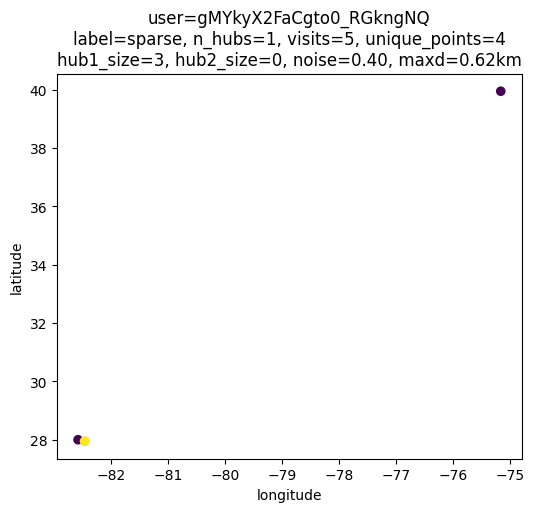

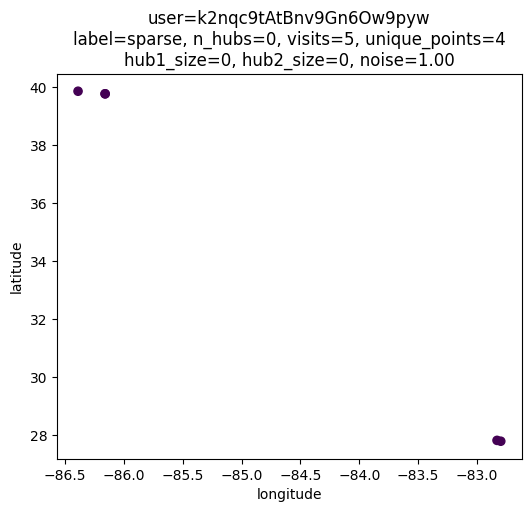

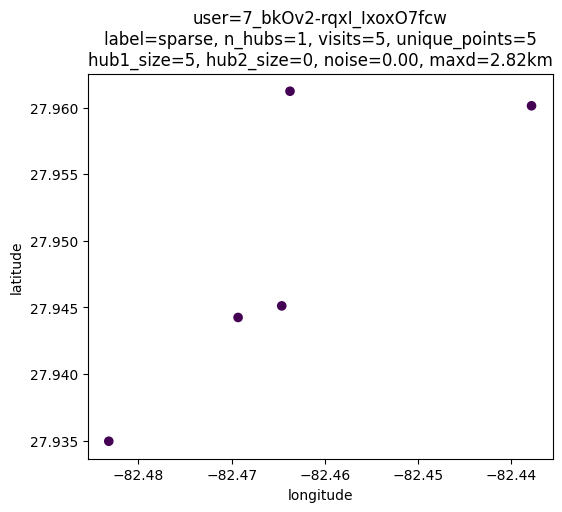

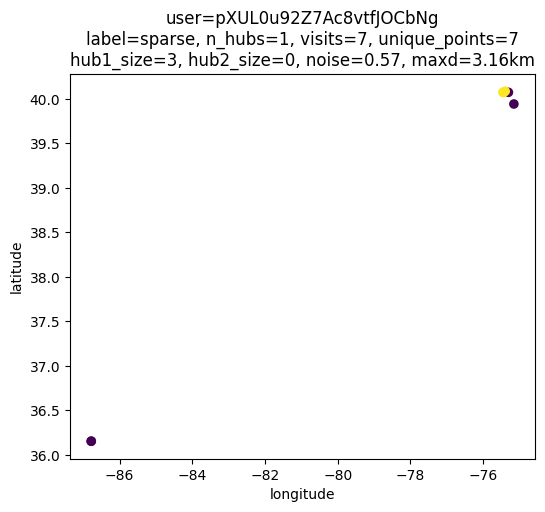


LABEL: one_area | USERS: ['sy7tdUjMzbCMdB1kFMyHJg', '0SW6-0e8NXaLPyMiUMWlgw', 'HTLso7W2jX_fTZ7NCXJGtg', 'oJCRGi311azjaB-LwdpMiQ']


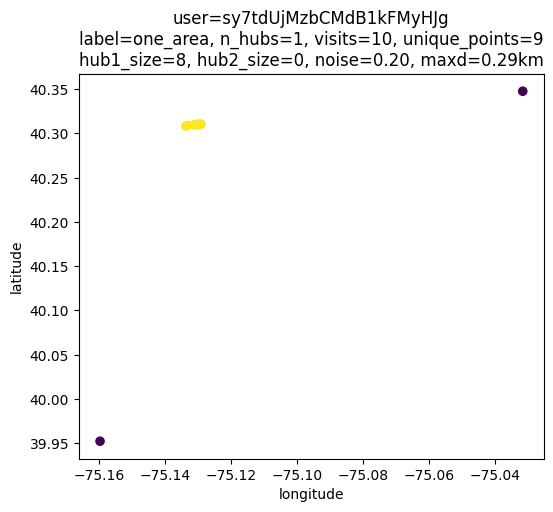

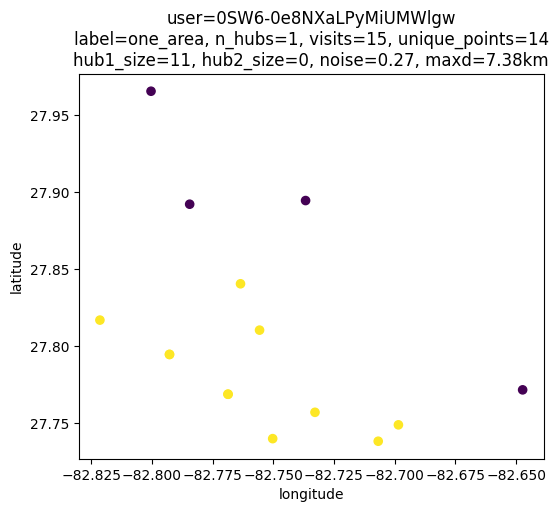

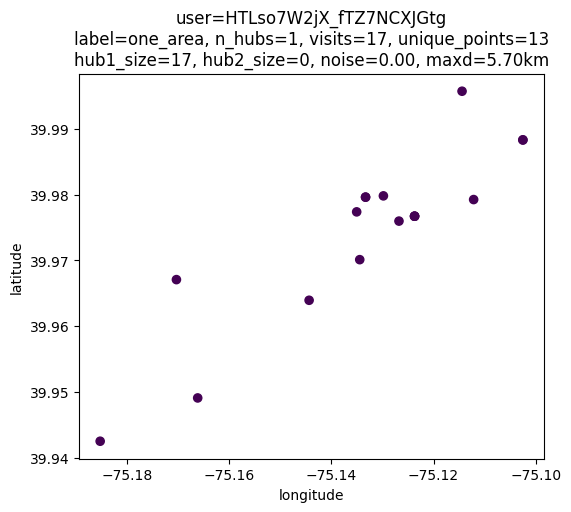

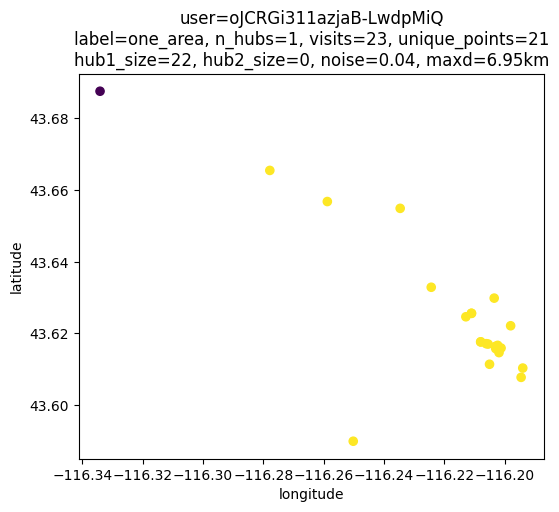


LABEL: two_area | USERS: ['Kc-kC8eu_U8mH87cOYvqbQ', '-8lbUNlXVSoXqaRRiHiSNg', 'FbCoRdahscG4l0TWZj5LJA', 'LRx0RViGEAFX2UVJ5bNBRg']


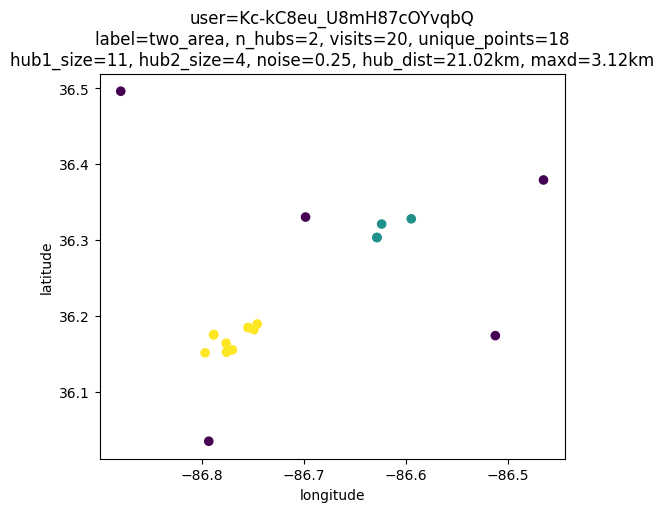

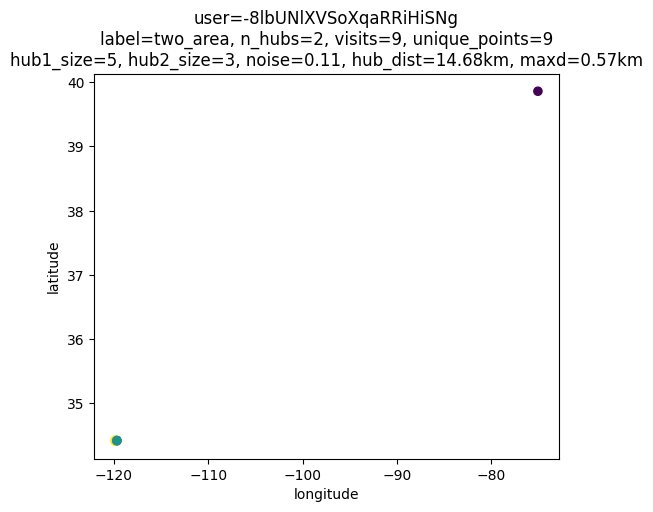

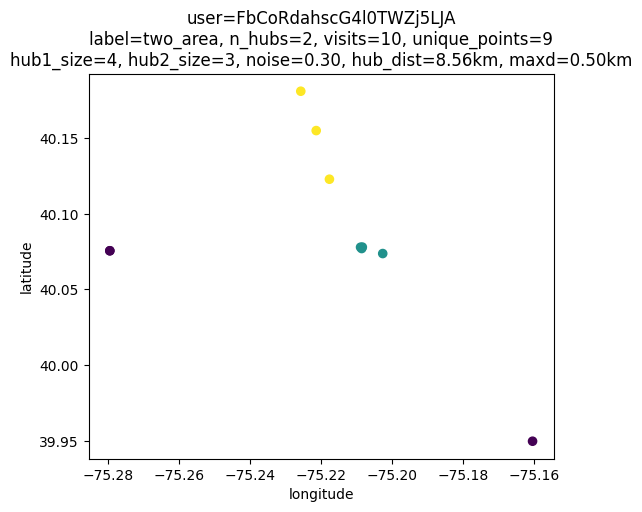

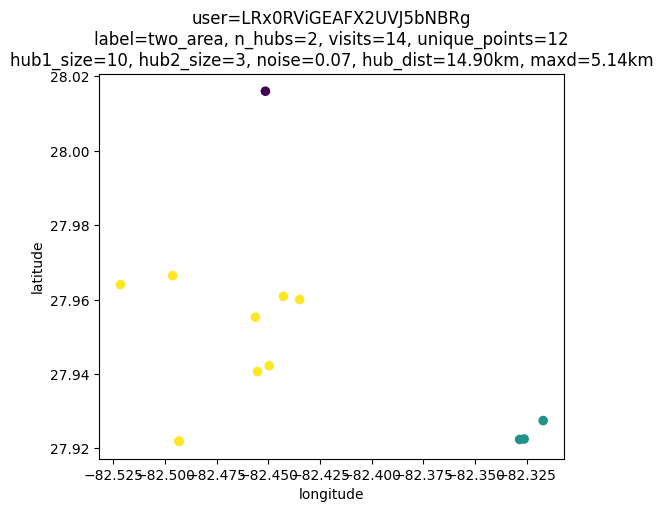


LABEL: explorer | USERS: ['QfFIPbAYkrMD0SPMTNP4cQ', '328rVFXP8uJQjh8vy7HZ4Q', 'sz-6iY15Ukhcgc4CFJJ3xg', 'Up-oM-OL17jDjn0GxtwH1Q']


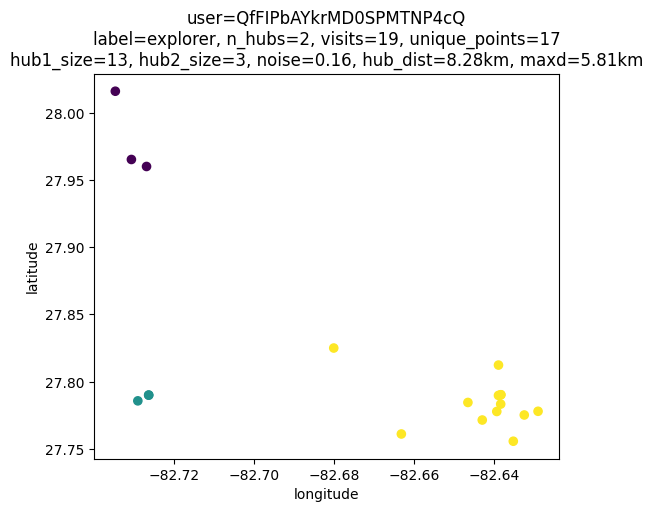

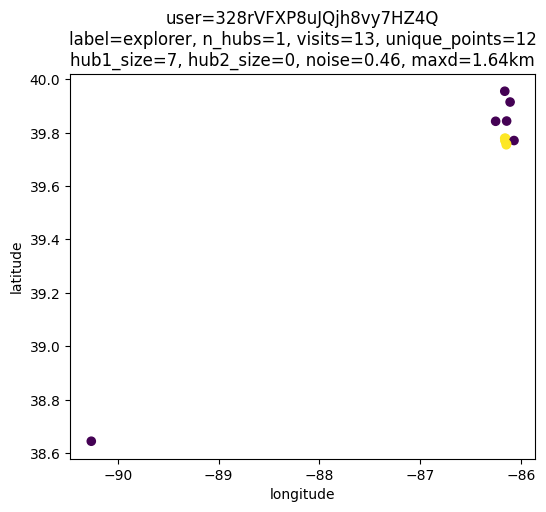

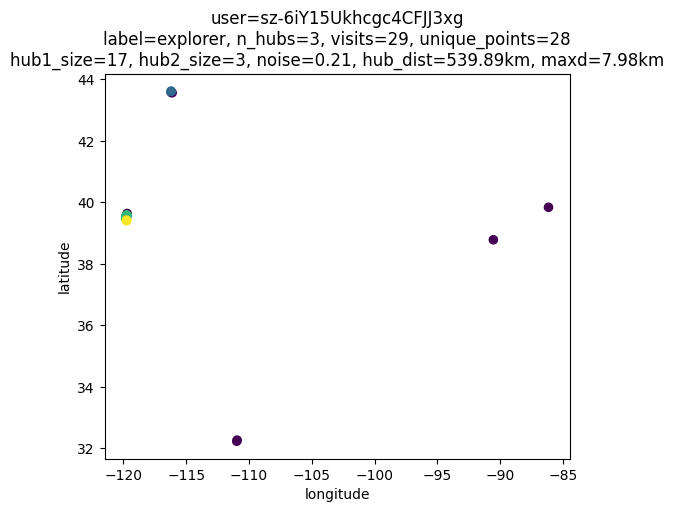

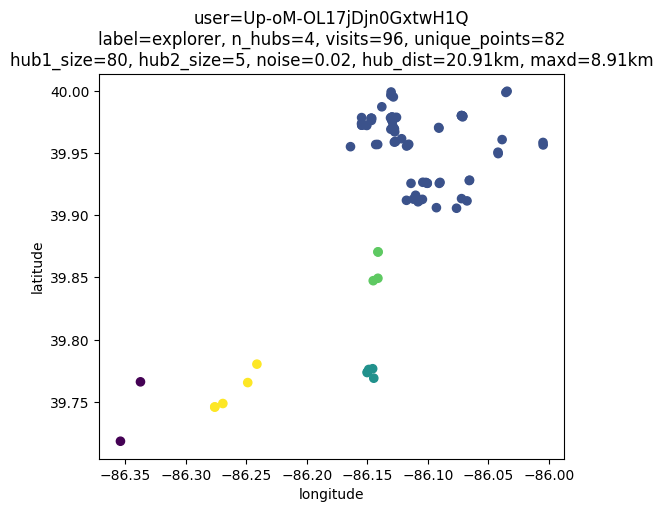

In [48]:
def sample_users_by_label(pop_df, label, n=4, random_state=42):
    subset = pop_df[pop_df["mobility_label"] == label]
    if len(subset) == 0:
        return []
    return subset.sample(min(n, len(subset)), random_state=random_state)["user_id"].tolist()

for label in ["sparse", "one_area", "two_area", "explorer"]:
    users = sample_users_by_label(pop_final, label, n=4, random_state=42)
    print(f"\nLABEL: {label} | USERS: {users}")
    for uid in users:
        plot_user_clusters(uid, visits, pop_final)

In [49]:
cols = [
    "user_id",
    "mobility_label",
    "n_visits",
    "n_unique_points",
    "n_hubs",
    "hub1_size",
    "hub2_size",
    "hub1_share",
    "hub2_share",
    "noise_ratio",
    "clustered_share",
    "hub_dist_km",
    "travel_range_km",
    "max_dist_from_primary_hub_km",
]

display(
    pop_final.loc[pop_final["mobility_label"] == "one_area", cols]
    .sort_values(["max_dist_from_primary_hub_km", "noise_ratio"], ascending=[False, False])
    .head(10)
)

display(
    pop_final.loc[pop_final["mobility_label"] == "two_area", cols]
    .sort_values(["hub_dist_km", "hub2_size"], ascending=[False, True])
    .head(10)
)

,user_id,mobility_label,n_visits,n_unique_points,n_hubs,hub1_size,hub2_size,hub1_share,hub2_share,noise_ratio,clustered_share,hub_dist_km,travel_range_km,max_dist_from_primary_hub_km
119,4v9Wc4MX0A6HHGfkghbhZg,one_area,47,38,1,45,0,1.0,0.0,0.042553,0.957447,NaN,10.911430,20.378843
603,W81s2EdHHq4_CYDJNqhgRg,one_area,203,136,1,198,0,1.0,0.0,0.024631,0.975369,NaN,5.408322,16.727727
1059,v2uq7UUFJqaRSQNcd5K-xw,one_area,47,46,1,38,0,1.0,0.0,0.191489,0.808511,NaN,6.768195,13.951468
232,Anx6fA6jHXmLS7oaUFXJcw,one_area,135,93,1,133,0,1.0,0.0,0.014815,0.985185,NaN,2.024907,13.271728
248,BRk2yc1ax9NVPhBzhWGKJg,one_area,26,25,1,24,0,1.0,0.0,0.076923,0.923077,NaN,6.977325,13.175462
313,EmFmu3jzYIhbRf-Pn4MSCg,one_area,31,28,1,29,0,1.0,0.0,0.064516,0.935484,NaN,6.484840,13.042667
1130,yaDSKPoiZe13cCZtAU15vA,one_area,46,45,1,40,0,1.0,0.0,0.130435,0.869565,NaN,6.405893,12.376292
995,rNm9bItfqHT4Y2_tXsjL2Q,one_area,55,41,1,55,0,1.0,0.0,0.000000,1.000000,NaN,2.853112,12.334013
405,KAozHo6DpWCn0Mz6nvJLoQ,one_area,17,16,1,13,0,1.0,0.0,0.235294,0.764706,NaN,6.343389,12.134927
1133,yiu7X_J6RFh8-7Dn-pKPkg,one_area,20,20,1,19,0,1.0,0.0,0.050000,0.950000,NaN,5.626835,11.491101


,user_id,mobility_label,n_visits,n_unique_points,n_hubs,hub1_size,hub2_size,hub1_share,hub2_share,noise_ratio,clustered_share,hub_dist_km,travel_range_km,max_dist_from_primary_hub_km
1127,yXhsuwDpKVD2vPdT3H5qow,two_area,17,17,2,12,3,0.800000,0.200000,0.117647,0.882353,47.111965,1.465241,6.473226
304,EWBOMeX_OIcAWXuvs_4SKw,two_area,15,14,2,7,5,0.583333,0.416667,0.200000,0.800000,41.931187,1.104552,1.637691
176,7a5xVAMhxn9StliGtvyVXw,two_area,13,12,2,7,5,0.583333,0.416667,0.076923,0.923077,35.653631,1.034748,2.323713
831,jF2NWMxcrPsZCiZ0z8jJSg,two_area,19,15,2,12,4,0.750000,0.250000,0.157895,0.842105,34.692044,1.287449,4.477739
499,Po-IIg0JO24jfgou7bDqrg,two_area,9,9,2,5,3,0.625000,0.375000,0.111111,0.888889,31.422219,1.616246,3.442571
69,2Hdot8bpjmvtBLLZWXOPMQ,two_area,11,8,2,6,5,0.545455,0.454545,0.000000,1.000000,30.097566,0.711425,3.239979
125,51Mzh0f6vH0-ZiXj9jFVhw,two_area,10,10,2,5,3,0.625000,0.375000,0.200000,0.800000,26.679704,2.131611,4.629704
22,-psFb4sFsOm0oRLY2Kye0A,two_area,28,26,2,14,11,0.560000,0.440000,0.107143,0.892857,25.720816,3.210139,7.938069
314,Eo8lE6YTCdepIe6jFBLY8g,two_area,12,12,2,6,3,0.666667,0.333333,0.250000,0.750000,25.466638,2.438264,2.983931
460,NK2rEuA_ZJ6Jw94hPmNkLw,two_area,13,12,2,6,4,0.600000,0.400000,0.230769,0.769231,25.305027,2.150430,2.536655


In [54]:
report_table = pop_final["mobility_label"].value_counts(normalize=True).mul(100).round(2)
report_table

mobility_label
sparse      50.47
one_area    22.09
explorer    20.45
two_area     6.99
Name: proportion, dtype: float64

In [55]:
pop_final.groupby("mobility_label")[["n_visits", "n_unique_points", "n_hubs", "travel_range_km"]].median()

,n_visits,n_unique_points,n_hubs,travel_range_km
mobility_label,,,,
explorer,17.0,15.0,2.0,1.787868
one_area,13.0,12.0,1.0,1.766555
sparse,6.0,5.0,1.0,1.255957
two_area,13.0,12.0,2.0,1.465241


suspect_one_area: ['4v9Wc4MX0A6HHGfkghbhZg', 'W81s2EdHHq4_CYDJNqhgRg', 'v2uq7UUFJqaRSQNcd5K-xw']
suspect_two_area: ['yXhsuwDpKVD2vPdT3H5qow', 'EWBOMeX_OIcAWXuvs_4SKw', '7a5xVAMhxn9StliGtvyVXw']


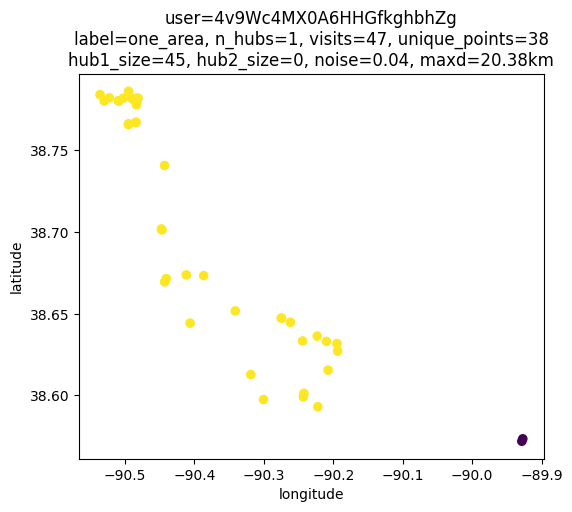

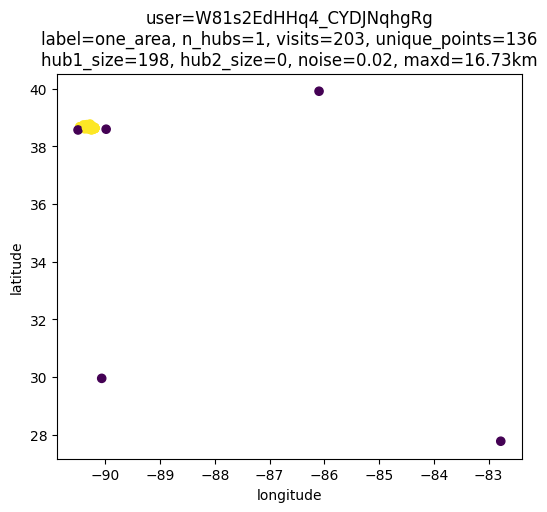

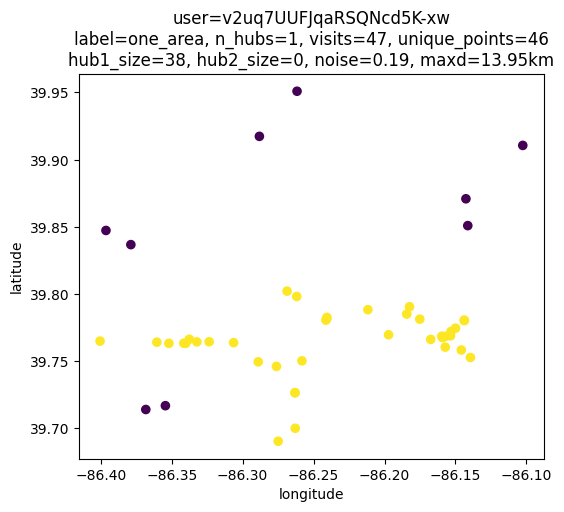

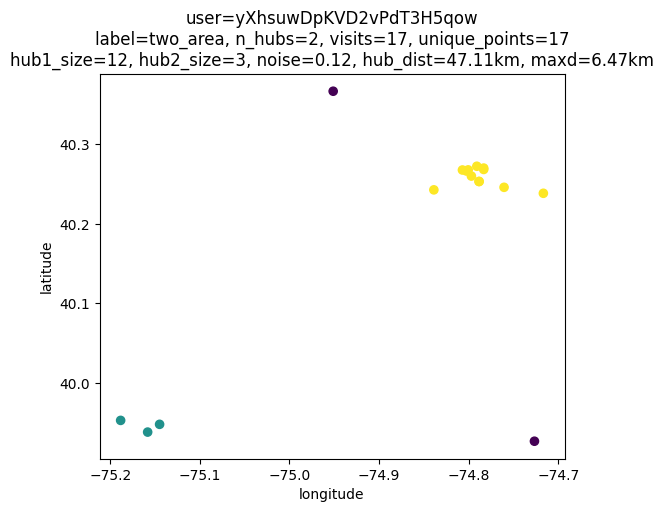

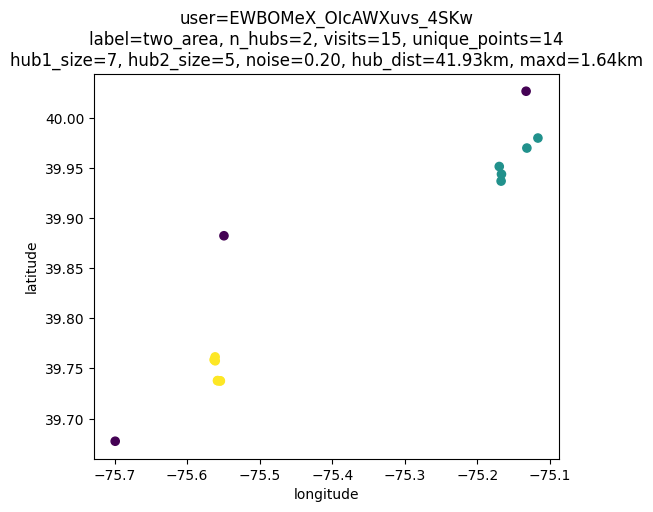

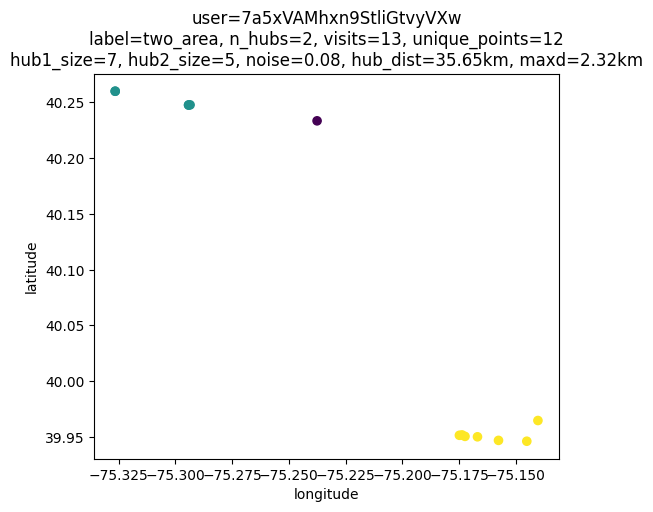

In [53]:
suspect_one_area = (
    pop_final.loc[pop_final["mobility_label"] == "one_area"]
    .sort_values(["max_dist_from_primary_hub_km", "noise_ratio"], ascending=[False, False])
    .head(3)["user_id"]
    .tolist()
)

suspect_two_area = (
    pop_final.loc[pop_final["mobility_label"] == "two_area"]
    .sort_values(["hub_dist_km", "hub2_size"], ascending=[False, True])
    .head(3)["user_id"]
    .tolist()
)

print("suspect_one_area:", suspect_one_area)
print("suspect_two_area:", suspect_two_area)

for uid in suspect_one_area + suspect_two_area:
    plot_user_clusters(uid, visits, pop_final)